## Importando as Bibliotecas

In [85]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Leitura da Base de Dados

In [86]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


# 1. Limpeza, Tokenização e Remoção das StopWords

In [87]:
df_teste = dados.copy()

In [88]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

In [89]:
STOP_WORDS = set(stopwords.words("portuguese"))

NEGACAO = {"não", "nao", "nunca", "nem", "sem"}

STOP_WORDS_PT = STOP_WORDS - NEGACAO

In [90]:
def pipeline_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)
    # 5. Expande contrações
    # Primeiro quebra o texto em palavras (texto.split())
    # Depois troca as contrações no dicionário (CONTRACTIONS)
    # Por fim junta tudo
    palavras = [CONTRACTIONS.get(p,p) for p in texto.split()]
    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()


    return texto

In [91]:
df_teste["texto_tratado"] = df_teste["review_comment_message"].apply(pipeline_texto)

df_teste[["review_comment_message", "texto_tratado"]].head()

,review_comment_message,texto_tratado
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...","vendedor confiável, produto ok e entrega antes..."


# 2. Modelo Embedding

In [92]:
from sentence_transformers import SentenceTransformer

modelo_embedding = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [93]:
texto = "O produto chegou antes do prazo e gostei muito"

# transformando a frase em um vetor de 384
embedding = modelo_embedding.encode(texto)

print(embedding.shape)
print(embedding[:10])

(384,)
[-0.11630476  0.1825614  -0.13466714 -0.17516565 -0.09923282  0.07612666
 -0.05354375  0.27536932  0.09463998 -0.10428396]


# 3. Divisão dos Dados em Treino e Teste

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
sentimento = {
    "negativo": 0,
    "positivo": 1
}
dados["sentimento"] = dados["sentimento"].map(sentimento)

In [96]:
dados["review"] = dados["review_comment_message"].apply(pipeline_texto)
dados.head()

,review_comment_message,review_score,sentimento,review
3,Recebi bem antes do prazo estipulado.,5,1,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,5,1,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,4,1,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,1,"mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...",5,1,"vendedor confiável, produto ok e entrega antes..."


In [97]:
X = dados["review"]
y = dados["sentimento"]

In [98]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

print(f"Dados de Treino -> {len(X_treino)}")
print(f"Dados de Teste -> {len(X_teste)}")

Dados de Treino -> 26194
Dados de Teste -> 11226


# 4. Aplicando o Embedding nos Dados

In [99]:

X_treino_embeddings = modelo_embedding.encode(
    X_treino.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

X_teste_embeddings = modelo_embedding.encode(
    X_teste.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)


Batches:   0%|          | 0/410 [00:00<?, ?it/s]

Batches:   0%|          | 0/176 [00:00<?, ?it/s]

* Salvando os embeddings para quando quiser usar de novo

In [100]:
np.save("../data/embedding/X_treino_embeddings.npy", X_treino_embeddings)

np.save("../data/embedding/X_teste_embeddings.npy", X_teste_embeddings)

* Para chamar já os embeddings prontos

In [101]:
#X_treino_embeddings = np.load("../data/embedding/X_treino_embeddings.npy")
#X_teste_embeddings = np.load("../data/embedding/X_teste_embeddings.npy")

In [102]:
print(f"Treino -> {X_treino_embeddings.shape}")
print(f"Teste -> {X_teste_embeddings.shape}")

Treino -> (26194, 384)
Teste -> (11226, 384)


# 5. Aplicando Modelos de Machine Learning

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

## Modelo Regressão Logística

In [104]:
modelo_rl = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

modelo_rl.fit(X_treino_embeddings, y_treino)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [105]:
previsao_rl = modelo_rl.predict(X_teste_embeddings)

print("=== Resultados Regressão Logística ===")
print(classification_report(y_teste, previsao_rl))

=== Resultados Regressão Logística ===
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.92     11226
   macro avg       0.90      0.93      0.91     11226
weighted avg       0.93      0.92      0.93     11226



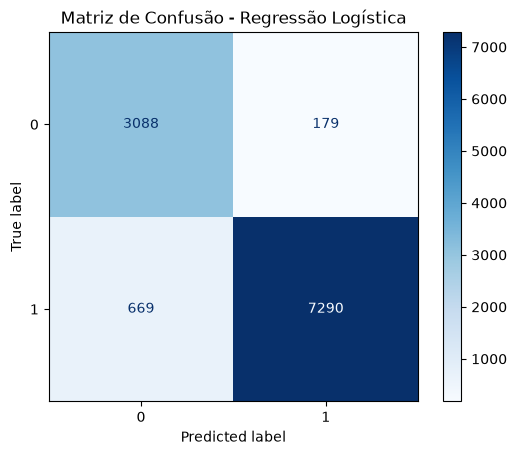

In [106]:
ConfusionMatrixDisplay.from_estimator(modelo_rl, X_teste_embeddings, y_teste, cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

## Modelo SVM

In [107]:
modelo_svm = LinearSVC(class_weight="balanced", random_state=42)

modelo_svm.fit(X_treino_embeddings, y_treino)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

In [108]:
previsao_svm = modelo_svm.predict(X_teste_embeddings)

print("=== SVM + Embeddings ===")
print(classification_report(y_teste, previsao_svm))

=== SVM + Embeddings ===
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.90      0.93      0.91     11226
weighted avg       0.93      0.93      0.93     11226



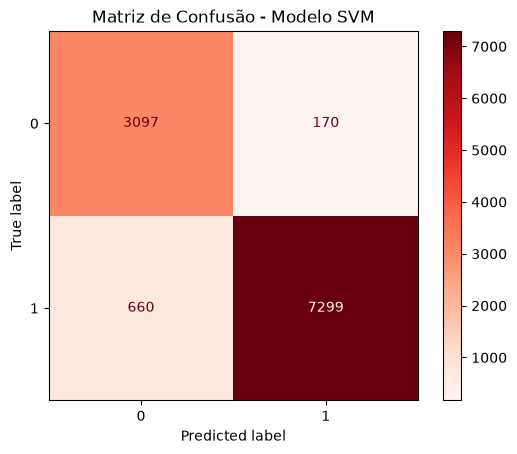

In [109]:
ConfusionMatrixDisplay.from_estimator(modelo_svm, X_teste_embeddings, y_teste, cmap="Reds")
plt.title("Matriz de Confusão - Modelo SVM")
plt.show()

# 6. Aplicando a Otimização por GridSearchCV

In [111]:
from sklearn.model_selection import GridSearchCV, learning_curve, StratifiedKFold


## Otimização Regressão Logistica

In [119]:
modelo_rl_base = LogisticRegression(random_state=42, class_weight="balanced")

param_grid_lr = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "max_iter": [1000, 2000, 3000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rl = GridSearchCV(
    estimator=modelo_rl_base,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="f1_macro"
)

grid_rl.fit(X_treino_embeddings, y_treino)

print(f"Melhor Score -> {grid_rl.best_score_}")
print(f"Melhores Hiperparametros -> {grid_rl.best_params_}")

Melhor Score -> 0.9101678152308355
Melhores Hiperparametros -> {'C': 10, 'max_iter': 1000}


## Otimização SVM

In [120]:
modelo_svm_base = LinearSVC(random_state=42, class_weight="balanced")

param_grid_svm = {
    "C": [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10],
}

grid_svm = GridSearchCV(
    estimator=modelo_svm_base,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="f1_macro"
)

grid_svm.fit(X_treino_embeddings, y_treino)

print(f"Melhor Score -> {grid_svm.best_score_}")
print(f"Melhores Hiperparametros -> {grid_svm.best_params_}")

Melhor Score -> 0.9112187808198706
Melhores Hiperparametros -> {'C': 10}


## Resultados Otimização GridSearchCV

In [121]:
modelos_otimizados = {
    "Regressão Logística Otimizado": grid_rl.best_estimator_,
    "SVM Otimizado": grid_svm.best_estimator_
}

for nome, modelo in modelos_otimizados.items():
    previsao = modelo.predict(X_teste_embeddings)

    print(f"{nome} Otimizado")
    print(classification_report(y_teste, previsao))
    print('-'*60)

Regressão Logística Otimizado Otimizado
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.90      0.93      0.91     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------
SVM Otimizado Otimizado
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.90      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226

------------------------------------------------------------


In [122]:
modelo_rl_otimizado = grid_rl.best_estimator_
modelo_svm_otimizado = grid_svm.best_estimator_

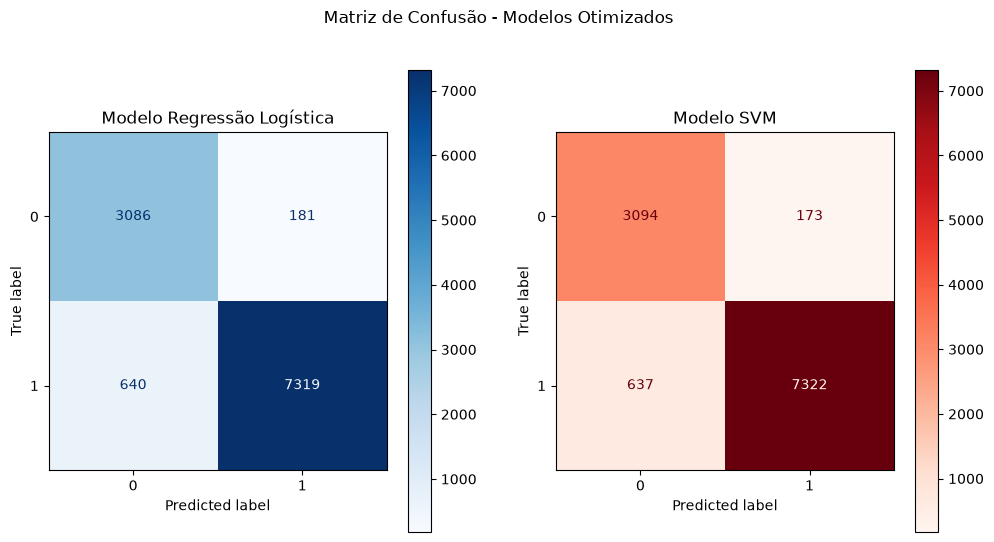

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

ConfusionMatrixDisplay.from_estimator(modelo_rl_otimizado, X_teste_embeddings, y_teste, cmap="Blues", ax=axes[0])
axes[0].set_title("Modelo Regressão Logística")

ConfusionMatrixDisplay.from_estimator(modelo_svm_otimizado, X_teste_embeddings, y_teste, cmap="Reds", ax=axes[1])
axes[1].set_title("Modelo SVM")

plt.suptitle("Matriz de Confusão - Modelos Otimizados")
plt.show()

# 7. Visualizando o Learning Curve

In [124]:
train_sizes, train_score, val_score = learning_curve(
    estimator=modelo_svm_otimizado,
    X=X_treino_embeddings,
    y=y_treino,
    train_sizes=np.linspace(0.1, 1, 10),
    cv=cv,
    scoring="f1_macro"
)

train_mean = train_score.mean(axis=1)
train_std = train_score.std(axis=1)

val_mean = val_score.mean(axis=1)
val_std = val_score.std(axis=1)

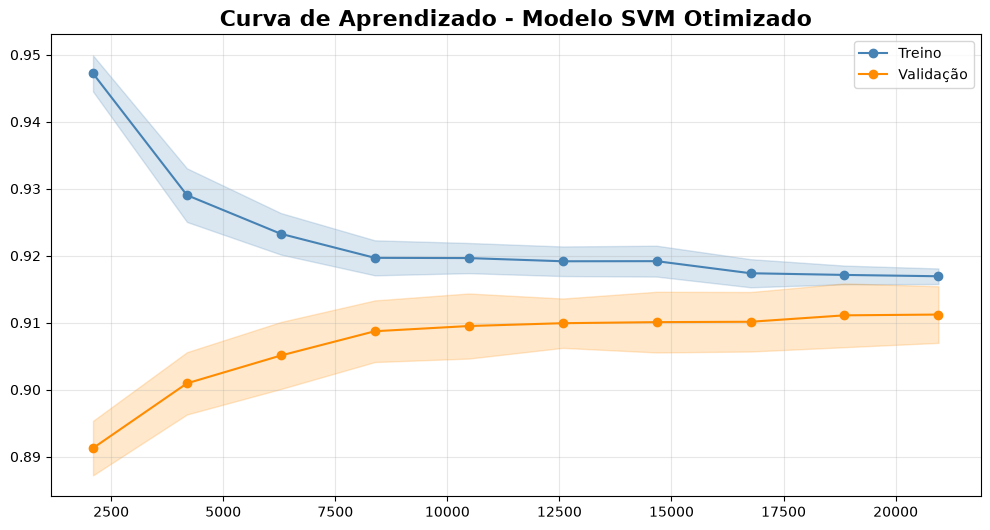

In [126]:
plt.figure(figsize=(12,6))

# Plotando Treino
plt.plot(train_sizes, train_mean, color="steelblue", marker='o', label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="steelblue",alpha=0.2)

# Plotando Validação
plt.plot(train_sizes, val_mean, color="darkorange", marker='o', label="Validação")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="darkorange", alpha=0.2)

plt.title("Curva de Aprendizado - Modelo SVM Otimizado", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [127]:
gap_final = train_mean[-1] - val_mean[-1]

print(f"Valor Final Treino -> {train_mean[-1]:.2f}")
print(f"Valor Final Validação -> {val_mean[-1]:.2f}")
print(f"Gap Final -> {gap_final:.2f}")

Valor Final Treino -> 0.92
Valor Final Validação -> 0.91
Gap Final -> 0.01


# 8. Visualizando Resultado dos Testes

In [130]:
previsao_final = modelo_svm_otimizado.predict(X_teste_embeddings)

print("=== Resultados Finais SVM Otimizado ===")
print(classification_report(y_teste, previsao_final))

=== Resultados Finais SVM Otimizado ===
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      3267
           1       0.98      0.92      0.95      7959

    accuracy                           0.93     11226
   macro avg       0.90      0.93      0.92     11226
weighted avg       0.93      0.93      0.93     11226



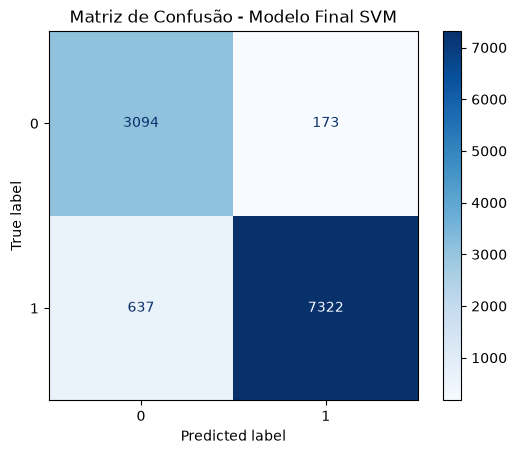

In [131]:
ConfusionMatrixDisplay.from_predictions(y_teste, previsao_final, cmap="Blues")
plt.title("Matriz de Confusão - Modelo Final SVM")
plt.show()